In [7]:
from functions import *
from tqdm import tqdm
import os

### Der Datensatz wird geladen, wird daraus ein Datenrahmen erstellt und nutzlose Dateien werden gelöscht

In [8]:
input_path = []
label = []

# Pfad zum Verzeichnis, das die Daten enthält
data_directory = 'Final_Training/Images/'
number_class = 43

      
for i in range(number_class):
    
    num_zeros = 5  # die Anzahl der Zeichen, aus denen der Klassenname besteht
    class_name = f"{i:0{num_zeros}d}" #Der Klassenname setzt sich aus dem Wert von i und den davor stehenden Nullen zusammen, wobei die Gesamtzahl der Zeichen des Klassennamens berücksichtigt wird
    class_path = os.path.join(data_directory, class_name)
    #print(class_path)
        
        

    for image_path in os.listdir(class_path):
            label.append(class_name)
            input_path.append(os.path.join(class_path, image_path))


print("Die Größe der Eingabe beträgt : ", len(input_path))           
  

Die Größe der Eingabe beträgt :  39252


In [9]:
import pandas as pd

# DataFrame erstellen und mit Bildpfaden und Labels füllen
df = pd.DataFrame()
df['images'] = input_path
df['label'] = label

# DataFrame zufällig mischen und den Index zurücksetzen
df = df.sample(frac=1).reset_index(drop=True)


# Die ersten Zeilen des DataFrame anzeigen
df.head()



,images,label
0,Final_Training/Images/00025\00014_00025.ppm,00025
1,Final_Training/Images/00031\00020_00021.ppm,00031
2,Final_Training/Images/00010\00010_00016.ppm,00010
3,Final_Training/Images/00033\00011_00006.ppm,00033
4,Final_Training/Images/00038\00029_00015.ppm,00038


In [10]:
# Anzeigen von Dateien , die nicht die Erweiterung .ppm haben

falsh_datei = df[~df['images'].str.endswith('.ppm')]
print(falsh_datei)



                                         images  label
300    Final_Training/Images/00040\GT-00040.csv  00040
1147   Final_Training/Images/00038\GT-00038.csv  00038
1962   Final_Training/Images/00006\GT-00006.csv  00006
4409   Final_Training/Images/00020\GT-00020.csv  00020
4891   Final_Training/Images/00024\GT-00024.csv  00024
7231   Final_Training/Images/00021\GT-00021.csv  00021
7843   Final_Training/Images/00026\GT-00026.csv  00026
9475   Final_Training/Images/00041\GT-00041.csv  00041
9568   Final_Training/Images/00022\GT-00022.csv  00022
10652  Final_Training/Images/00030\GT-00030.csv  00030
10775  Final_Training/Images/00010\GT-00010.csv  00010
11028  Final_Training/Images/00017\GT-00017.csv  00017
11134  Final_Training/Images/00000\GT-00000.csv  00000
11686  Final_Training/Images/00036\GT-00036.csv  00036
12784  Final_Training/Images/00002\GT-00002.csv  00002
13152  Final_Training/Images/00014\GT-00014.csv  00014
13275  Final_Training/Images/00019\GT-00019.csv  00019
13927  Fin

In [12]:
#Löschen von Dateien, die nicht die Erweiterung .ppm haben

# Filtern von Zeilen, bei denen „Bilder“ nicht mit „.ppm“ enden, und Abrufen vom Index dieser Zeilen
index_to_drop = df[~df['images'].str.endswith('.ppm')].index # gibt den Datenrahmen der Elemente in der Bildspalte unseres Datenrahmens zurück und extrahiert dann die Indizes dieses Datenrahmens

# Löschen von Zeilen, die diesen Indizes entsprechen
df = df.drop(index_to_drop).reset_index(drop=True)

#Überprüfen, ob alle diese Dateien gelöscht sind
for i in df['images']:
    if '.ppm' not in i:
        print(i)
        

print(len(df))

39209


In [14]:
#Prüfen, ob kein fehlerhaftes Bild vorliegt.
import PIL
l = []
for image in df['images']:
    try:
        img = PIL.Image.open(image)
    except:
        l.append(image)
print(len(l))

0


#### ANZEIGE DER 43 VERSCHIEDENEN KLASSEN UND DER KLASSENVERTEILUNG, AUFTEILUNG DES DATENSATZES IN TRAININGS- UND VALIDIERUNGSDATENSATZ UND ANZEIGE DEREN VERTEILUNGEN

100%|██████████| 43/43 [00:00<00:00, 68.03it/s]


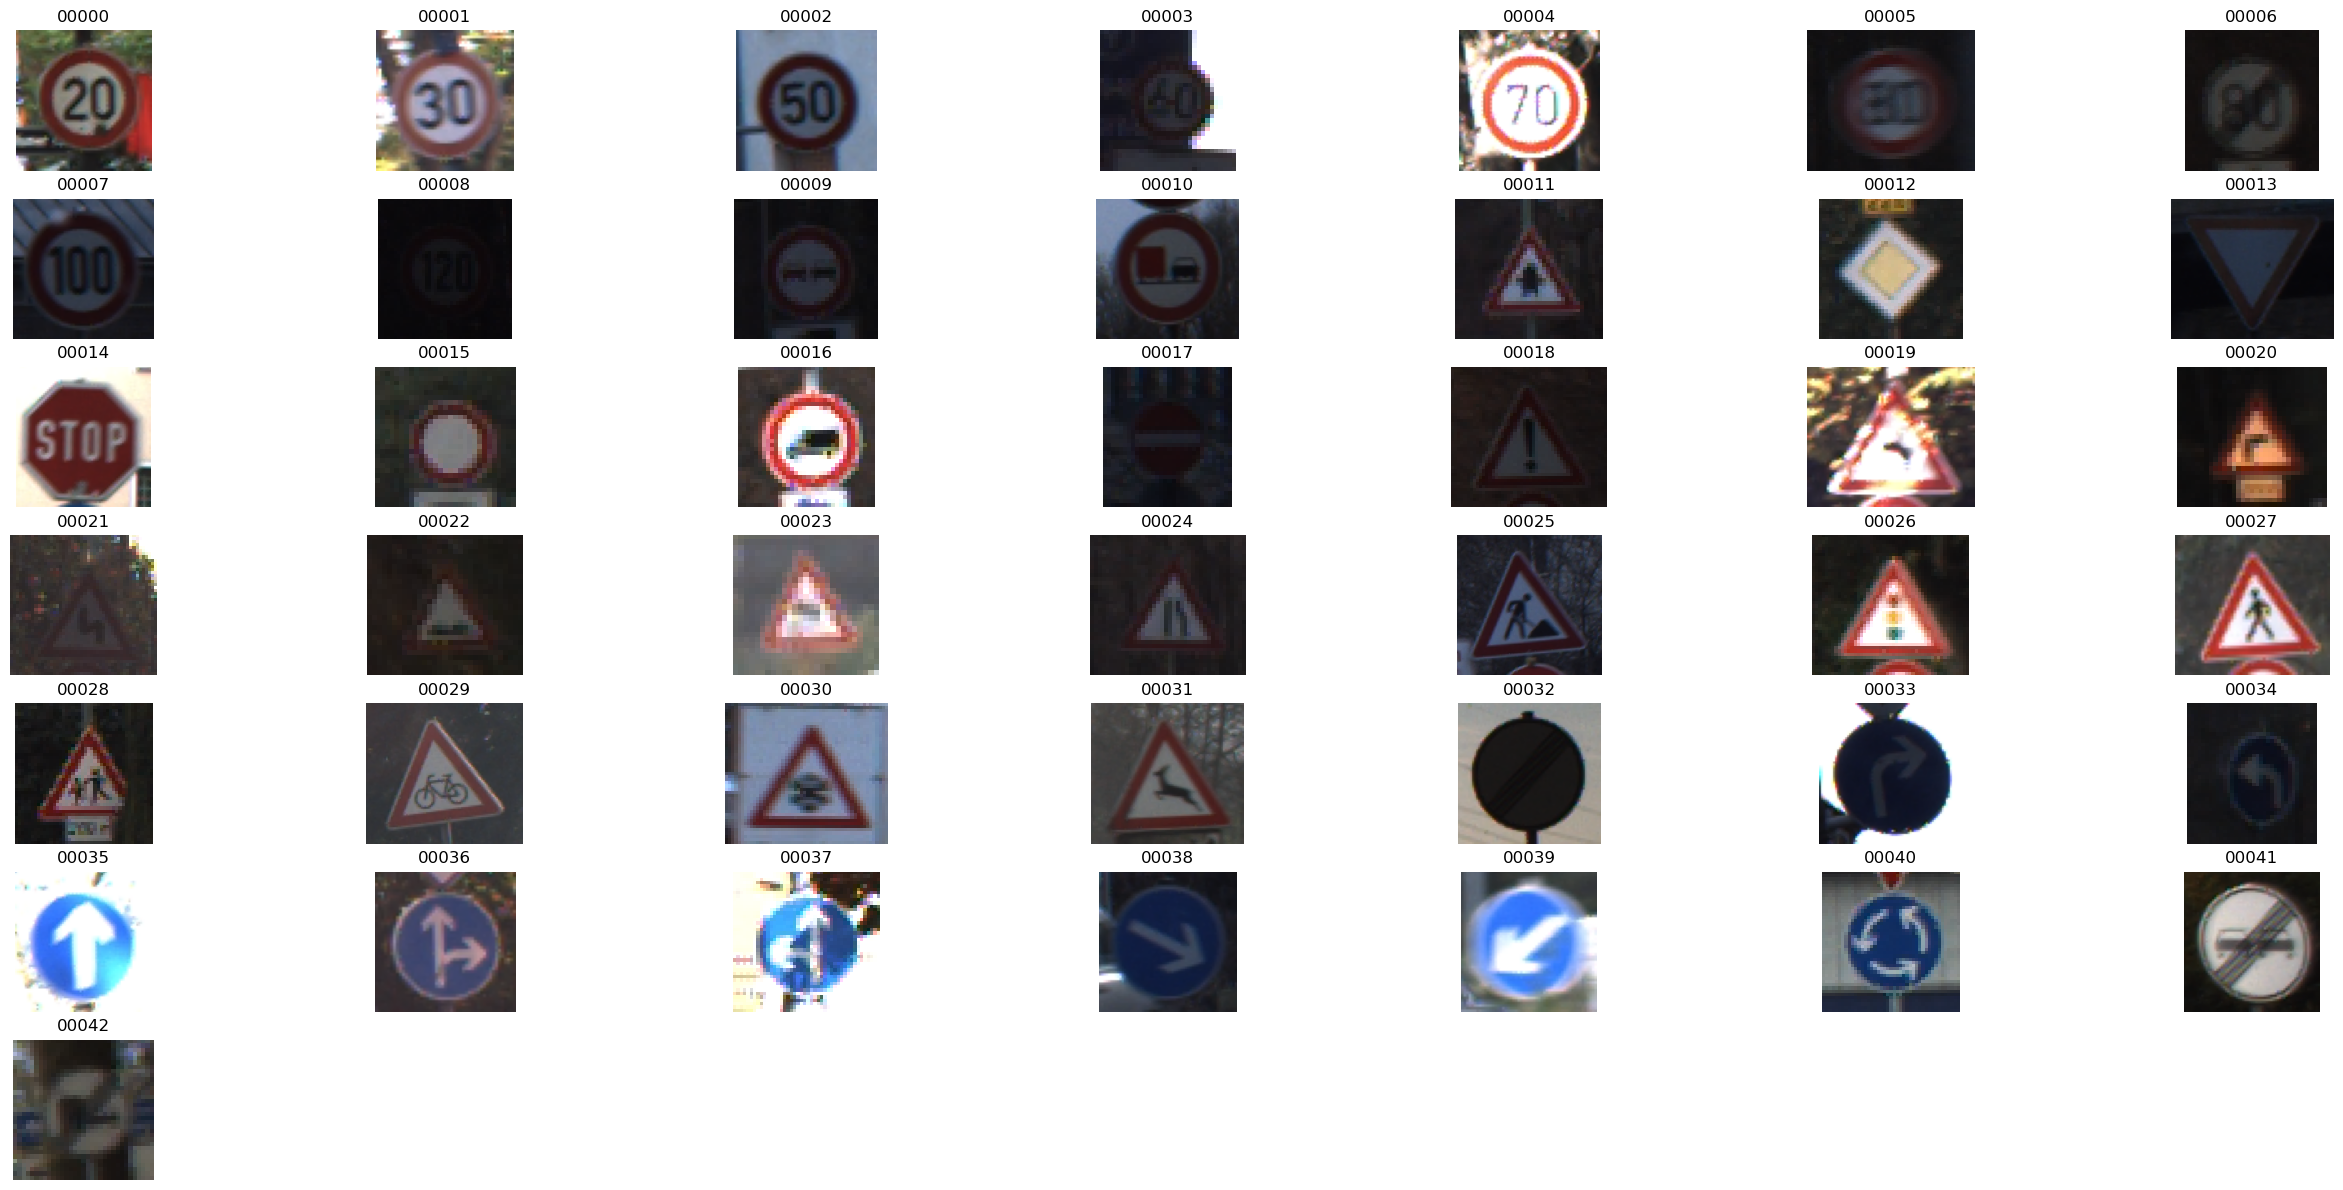

In [16]:
#Einblick in die 43 verschiedenen Klassen
load_all_data(df) #Diese funktion ist in functions.py definiert

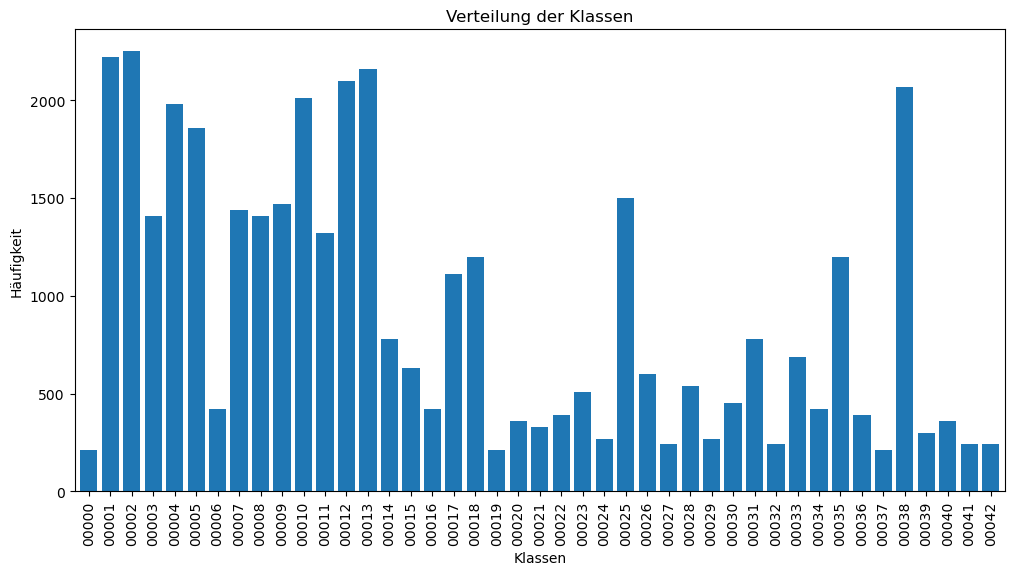

In [17]:
import matplotlib.pyplot as plt

# Klassenverteilungen im Datensatz
plt.figure(figsize=(12, 6))  # Größe des Diagramms anpassen
df['label'].value_counts().sort_index().plot(kind='bar', width=0.8)  # Breite der Balken anpassen mit dem Parameter width
plt.title('Verteilung der Klassen')  # Titel des Diagramms
plt.xlabel('Klassen')  # Beschriftung der x-Achse
plt.ylabel('Häufigkeit')  # Beschriftung der y-Achse
plt.show()

In [18]:
# Aufteilung der Eingabe in Trainingdatenssatz und Validierungsdatensatz(80% für training und 20% für Validierung)
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.1, random_state=42)


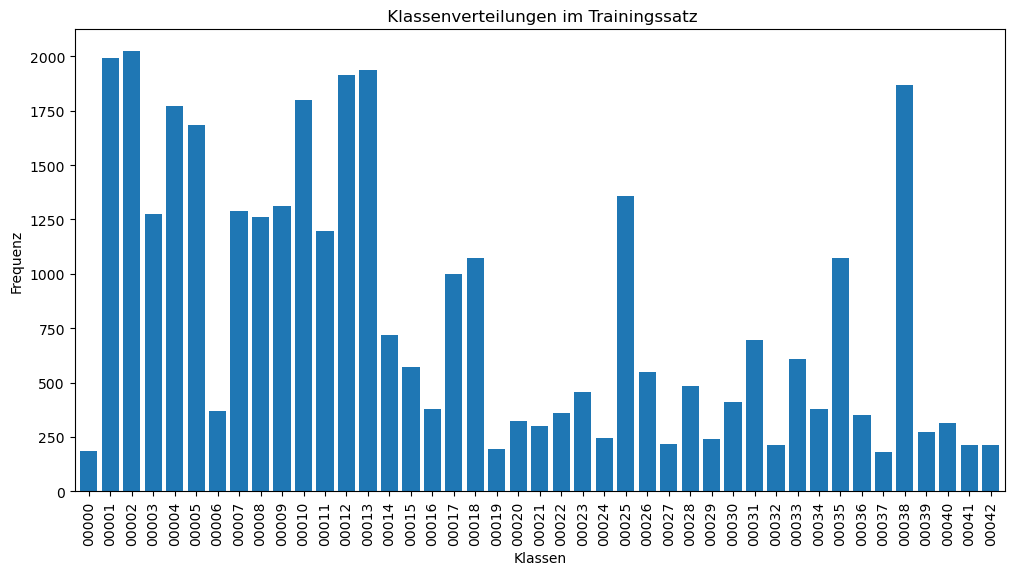

In [19]:
import matplotlib.pyplot as plt

#Klassenverteilungen im Trainingssatz
plt.figure(figsize=(12, 6))  # Größe des Diagramms anpassen
train['label'].value_counts().sort_index().plot(kind='bar', width=0.8)  # Breite der Balken anpassen mit dem Parameter width
plt.title(' Klassenverteilungen im Trainingssatz')
plt.xlabel('Klassen')
plt.ylabel('Frequenz')
plt.show()


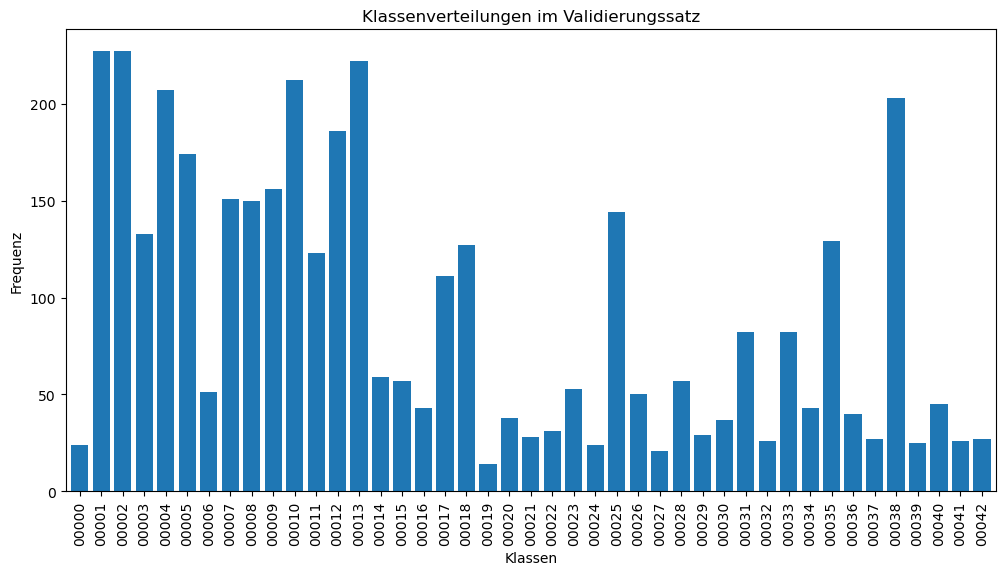

In [20]:
import matplotlib.pyplot as plt

#Klassenverteilung in dem Validierungsdatensatz
plt.figure(figsize=(12, 6))  # Größe des Diagramms anpassen
test['label'].value_counts().sort_index().plot(kind='bar', width=0.8)  # Breite der Balken anpassen mit dem Parameter width
plt.title('Klassenverteilungen im Validierungssatz')
plt.xlabel('Klassen')
plt.ylabel('Frequenz')
plt.show()


#### VORBEREITUNG DES TRAININGSDATENSATZES UND DES VALIDIERUNGSDATENSATZES FÜR DAS TRAINING UND DIE VALIDIERUNG

In [21]:
#Generator und Iterator für Trainingssatz und Validierungssatz

from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(
    
    rescale = 1./255, # Normalisierung von Bildern
    rotation_range = 40, #Vergrößerung von Bildern, um eine Überanpassung zu vermeiden
    shear_range = 0.2,
    zoom_range = 0.2,
    #horizontal_flip  = True, #Mit dieser Option, könnte eine Konfusion zwichen manchen Klassen haben.
    fill_mode = 'nearest'
    
)

val_generator = ImageDataGenerator(rescale = 1./255)

train_iterator = train_generator.flow_from_dataframe(
    
    train,
    x_col='images',
    y_col='label',
    target_size=(64,64),
    batch_size=512,
    class_mode='categorical'

)

val_iterator = val_generator.flow_from_dataframe(
    
    test,
    x_col='images',
    y_col='label',
    target_size=(64,64),
    batch_size=512,
    class_mode='categorical'


)

Found 35288 validated image filenames belonging to 43 classes.
Found 3921 validated image filenames belonging to 43 classes.


#### ERSTELLUNG DES MODELLS, TRAINIEREN ES UND AUFZEICHNUNG DES TRAININGSSTANDES

In [22]:
#Erstellung des Modells
from keras import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input
from keras import regularizers

number_classe = 43 #die Anzahl von Klassen

input_shape = (64, 64, 3)  # Grösse des Eingangs

model = Sequential()
model.add(Input(shape=input_shape))  # Separate Eingabeebene

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D((2,2)))
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPool2D((2,2)))
model.add(Conv2D(512, (3,3), activation='relu'))
model.add(MaxPool2D((2,2)))
model.add(Flatten())
model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.003)))
model.add(Dense(number_classe, activation='softmax'))


# Zusammenstellung des Modells mit der angepassten Verlustfunktion für die Mehrklassenklassifizierung
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 128)       │      3,584 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 128)       │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 256)       │    295,168 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 256)       │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)       │  1,180,160 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)         │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ flatten (Flatten)               │ (None, 18432)             │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense (Dense)                   │ (None, 512)               │  9,437,696 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense_1 (Dense)                 │ (None, 43)                │     22,059 │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 10,938,667 (41.73 MB)

 Trainable params: 10,938,667 (41.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25


C:\Users\KALIL\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


69/69 ━━━━━━━━━━━━━━━━━━━━ 478s 7s/step - accuracy: 0.1711 - loss: 4.0794 - val_accuracy: 0.5593 - val_loss: 1.6303
Epoch 2/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 524s 8s/step - accuracy: 0.6140 - loss: 1.4955 - val_accuracy: 0.8597 - val_loss: 0.7605
Epoch 3/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 533s 8s/step - accuracy: 0.8521 - loss: 0.8040 - val_accuracy: 0.8952 - val_loss: 0.6219
Epoch 4/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 518s 7s/step - accuracy: 0.9078 - loss: 0.5881 - val_accuracy: 0.9485 - val_loss: 0.4414
Epoch 5/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 504s 7s/step - accuracy: 0.9331 - loss: 0.4748 - val_accuracy: 0.9561 - val_loss: 0.3738
Epoch 6/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1102s 16s/step - accuracy: 0.9447 - loss: 0.4126 - val_accuracy: 0.9702 - val_loss: 0.3074
Epoch 7/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 469s 7s/step - accuracy: 0.9592 - loss: 0.3458 - val_accuracy: 0.9694 - val_loss: 0.2904
Epoch 8/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 498s 7s/step - accuracy: 0.9622 - loss: 0.3201 - val_accuracy: 0.9737 - val_loss: 

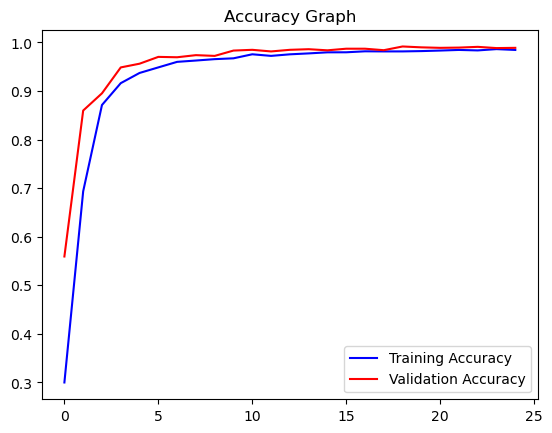

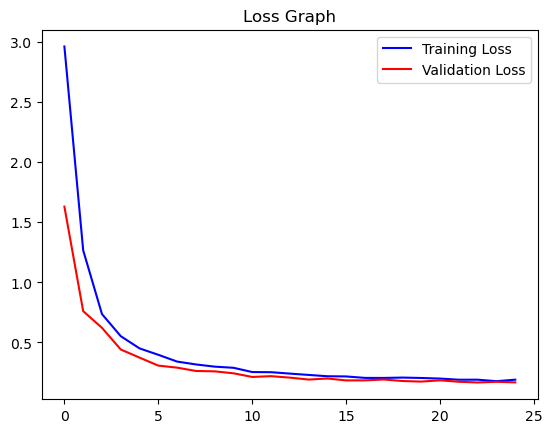

In [17]:
# Trainieren des Modells
history = model.fit(train_iterator, epochs=25, validation_data=val_iterator, verbose=1)

#Anzeigen der Grafik
plot_graph(history)

 #### BEWERTUNG DES MODELLS, SCHREIBEN ES AUF PLATTE

In [18]:
# Bewertung des Modells
scores = model.evaluate(val_iterator, verbose=1)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9891 - loss: 0.1661
compile_metrics: 98.88%


In [19]:
# Speichern des Modells und Architektur in einer einzigen Datei
from keras.models import save_model
from tensorflow.keras.models import save_model
#save_model(model, "model.v1.h5")
save_model(model, "model.final.keras")
print("Model saved to disk")

Model saved to disk


#### LADEN DES GESPEICHERTEN MODELLS UM ES WEITER ZU TRAINIEREN

In [36]:
# Laden des gespeicherten Modells
from tensorflow.keras.models import load_model
loaded_model = load_model('model.final.keras')
# summarize model.
#loaded_model.summary()

In [67]:
# Wieder Kompilieren des gespeicherten Modells 
#loaded_model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

In [68]:
#Weiter Trainieren des Modells
#history = loaded_model.fit(train_iterator, epochs=15, validation_data=val_iterator, verbose=1)

#Anzeigen der Grafik
#plot_graph(history)

In [69]:
#Wiederspeicherung des Modells
#save_model(loaded_model, "model.final.keras")

#### VORVERARBEITUNG DES TESTDATENSATZES

In [37]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np


test_images_folder = 'Final_Test/Images/'

# Erstellen einer Liste zum Speichern von Bildpfaden
path_images = []

# Durchsuchen des Testbildordner und sammeln von Pfaden
for name_image in os.listdir(test_images_folder):
    path_image = os.path.join(test_images_folder, name_image)
    path_images.append(path_image)
    

# Erstellen eines DataFrames für Bildpfade
df_test_images = pd.DataFrame({'path_images': path_images})
#print(df_test_images)

# Ladung der CSV-Datei mit Bildinformationen
infos_images = pd.read_csv('Final_Test/GT-final_test.csv', delimiter=';')

print("Data type in df_test_images:")
print(df_test_images.dtypes)

print("\nData type in  infos_images:")
print(infos_images.dtypes)

last_col = infos_images.columns[-1]
#print(last_col)

# In df_test_images wurde eine Spalte hinzugefügt, die die Namen der Bilddateien anstelle ihres Pfads enthält.
df_test_images['Filename'] = df_test_images['path_images'].apply(lambda x: os.path.basename(x))

# DataFrames in der Spalte „Filename“ zusammenführen
df_test = pd.merge(df_test_images, infos_images[['Filename', last_col]], on='Filename', how='inner')


# Kleiner Einblick des Datenframes
print(df_test.head())



Data type in df_test_images:
path_images    object
dtype: object

Data type in  infos_images:
Filename    object
Width        int64
Height       int64
Roi.X1       int64
Roi.Y1       int64
Roi.X2       int64
Roi.Y2       int64
ClassId      int64
dtype: object
                   path_images   Filename  ClassId
0  Final_Test/Images/00000.ppm  00000.ppm       16
1  Final_Test/Images/00001.ppm  00001.ppm        1
2  Final_Test/Images/00002.ppm  00002.ppm       38
3  Final_Test/Images/00003.ppm  00003.ppm       33
4  Final_Test/Images/00004.ppm  00004.ppm       11


In [38]:
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

# Grôsse der Bilder
target_size = (64, 64)# Zum weiteren Prufen
#batch_size = 32  

X_test = []
y_test = []

for index, row in df_test.iterrows():
    image_path = row['path_images']
    label = row['ClassId']

    # Laden und Vorverarbeitung der Bilder
    image = load_img(image_path, target_size=target_size)
    image_array = img_to_array(image) / 255.0  # Normalization
    X_test.append(image_array)
    
    y_test.append(label)

# Konvertieren der Listen in Numpy-Arrays
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Inhalt von X_test (images):")
print(X_test)

print("\nCInhalt von y_test (label):")
print(y_test)


Inhalt von X_test (images):
[[[[0.4509804  0.5411765  0.6784314 ]
   [0.45490196 0.5411765  0.6745098 ]
   [0.45490196 0.5372549  0.6627451 ]
   ...
   [0.3372549  0.43137255 0.5294118 ]
   [0.3137255  0.39607844 0.49411765]
   [0.24705882 0.32156864 0.4117647 ]]

  [[0.4627451  0.56078434 0.69803923]
   [0.45490196 0.54901963 0.69411767]
   [0.4509804  0.5411765  0.68235296]
   ...
   [0.47058824 0.5568628  0.67058825]
   [0.46666667 0.54509807 0.654902  ]
   [0.45882353 0.53333336 0.6509804 ]]

  [[0.45490196 0.56078434 0.69411767]
   [0.44313726 0.54509807 0.68235296]
   [0.4509804  0.54901963 0.68235296]
   ...
   [0.47058824 0.5529412  0.6784314 ]
   [0.46666667 0.54509807 0.6627451 ]
   [0.47058824 0.54509807 0.67058825]]

  ...

  [[0.45490196 0.53333336 0.654902  ]
   [0.45490196 0.53333336 0.64705884]
   [0.44705883 0.5254902  0.65882355]
   ...
   [0.45882353 0.53333336 0.64705884]
   [0.45490196 0.5411765  0.64705884]
   [0.44705883 0.54901963 0.65882355]]

  [[0.44705883 0.

#### VORHERSAGEN UND BERECHNUNG DER KONFUSIONSMATRIX UND GENAUIGKEIT DES MODELLS

In [39]:
from tqdm import tqdm

# Vorhersagen
predictions = loaded_model.predict(X_test, batch_size=512)

# Anzeigen vom Vorhersagenresultat
for i, prediction in tqdm(enumerate(predictions), total=len(predictions), desc='Prediction'):
    predicted_class = np.argmax(prediction)
    true_class = y_test[i]
    confidence = prediction[predicted_class]
    print(f"Image {i + 1} - Vorhersagen : {predicted_class}, Wahre Klasse : {true_class}, Vertrautheit : {confidence:.2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step


Prediction:  54%|█████▎    | 6758/12630 [00:00<00:00, 67214.85it/s]

Image 1 - Vorhersagen : 16, Wahre Klasse : 16, Vertrautheit : 1.00
Image 2 - Vorhersagen : 1, Wahre Klasse : 1, Vertrautheit : 1.00
Image 3 - Vorhersagen : 38, Wahre Klasse : 38, Vertrautheit : 1.00
Image 4 - Vorhersagen : 33, Wahre Klasse : 33, Vertrautheit : 0.99
Image 5 - Vorhersagen : 11, Wahre Klasse : 11, Vertrautheit : 1.00
Image 6 - Vorhersagen : 38, Wahre Klasse : 38, Vertrautheit : 1.00
Image 7 - Vorhersagen : 18, Wahre Klasse : 18, Vertrautheit : 1.00
Image 8 - Vorhersagen : 12, Wahre Klasse : 12, Vertrautheit : 0.99
Image 9 - Vorhersagen : 25, Wahre Klasse : 25, Vertrautheit : 1.00
Image 10 - Vorhersagen : 35, Wahre Klasse : 35, Vertrautheit : 1.00
Image 11 - Vorhersagen : 12, Wahre Klasse : 12, Vertrautheit : 0.96
Image 12 - Vorhersagen : 7, Wahre Klasse : 7, Vertrautheit : 1.00
Image 13 - Vorhersagen : 23, Wahre Klasse : 23, Vertrautheit : 0.99
Image 14 - Vorhersagen : 7, Wahre Klasse : 7, Vertrautheit : 0.74
Image 15 - Vorhersagen : 4, Wahre Klasse : 4, Vertrautheit : 1.

Image 7134 - Vorhersagen : 25, Wahre Klasse : 25, Vertrautheit : 1.00
Image 7135 - Vorhersagen : 12, Wahre Klasse : 12, Vertrautheit : 1.00
Image 7136 - Vorhersagen : 7, Wahre Klasse : 7, Vertrautheit : 1.00
Image 7137 - Vorhersagen : 38, Wahre Klasse : 38, Vertrautheit : 1.00
Image 7138 - Vorhersagen : 2, Wahre Klasse : 2, Vertrautheit : 1.00
Image 7139 - Vorhersagen : 13, Wahre Klasse : 13, Vertrautheit : 1.00
Image 7140 - Vorhersagen : 1, Wahre Klasse : 1, Vertrautheit : 1.00
Image 7141 - Vorhersagen : 12, Wahre Klasse : 12, Vertrautheit : 1.00
Image 7142 - Vorhersagen : 4, Wahre Klasse : 4, Vertrautheit : 1.00
Image 7143 - Vorhersagen : 26, Wahre Klasse : 26, Vertrautheit : 0.86
Image 7144 - Vorhersagen : 33, Wahre Klasse : 33, Vertrautheit : 1.00
Image 7145 - Vorhersagen : 7, Wahre Klasse : 7, Vertrautheit : 1.00
Image 7146 - Vorhersagen : 3, Wahre Klasse : 3, Vertrautheit : 1.00
Image 7147 - Vorhersagen : 40, Wahre Klasse : 40, Vertrautheit : 1.00
Image 7148 - Vorhersagen : 38, W

Prediction: 100%|██████████| 12630/12630 [00:00<00:00, 58200.14it/s]

Image 11095 - Vorhersagen : 5, Wahre Klasse : 5, Vertrautheit : 0.99
Image 11096 - Vorhersagen : 1, Wahre Klasse : 1, Vertrautheit : 1.00
Image 11097 - Vorhersagen : 13, Wahre Klasse : 13, Vertrautheit : 1.00
Image 11098 - Vorhersagen : 38, Wahre Klasse : 38, Vertrautheit : 1.00
Image 11099 - Vorhersagen : 1, Wahre Klasse : 1, Vertrautheit : 1.00
Image 11100 - Vorhersagen : 35, Wahre Klasse : 35, Vertrautheit : 0.77
Image 11101 - Vorhersagen : 13, Wahre Klasse : 13, Vertrautheit : 1.00
Image 11102 - Vorhersagen : 11, Wahre Klasse : 11, Vertrautheit : 1.00
Image 11103 - Vorhersagen : 13, Wahre Klasse : 13, Vertrautheit : 1.00
Image 11104 - Vorhersagen : 2, Wahre Klasse : 2, Vertrautheit : 0.99
Image 11105 - Vorhersagen : 4, Wahre Klasse : 4, Vertrautheit : 1.00
Image 11106 - Vorhersagen : 38, Wahre Klasse : 38, Vertrautheit : 1.00
Image 11107 - Vorhersagen : 25, Wahre Klasse : 25, Vertrautheit : 1.00
Image 11108 - Vorhersagen : 25, Wahre Klasse : 25, Vertrautheit : 1.00
Image 11109 - Vo

In [42]:
# Berechnung der Accuracy und Konfusionsmatrix

from sklearn.metrics import accuracy_score, confusion_matrix

# Umwandeln von Wahrscheinlichkeiten in vorhergesagte Klassen
predicted_classes = np.argmax(predictions, axis=1)

confusion_mat = confusion_matrix(y_test, predicted_classes)
accuracy = accuracy_score(y_test, predicted_classes)

print("Konfusionsmatrix :")
print(confusion_mat)

print(f"`\nGenauigkeit des Modells auf dem Testdatensatz : {accuracy * 100:.2f}%")

Konfusionsmatrix :
[[ 59   1   0 ...   0   0   0]
 [  0 706   2 ...   0   0   0]
 [  0   4 745 ...   0   0   0]
 ...
 [  0   0   0 ...  76   0   0]
 [  0   0   0 ...   0  55   0]
 [  0   0   0 ...   0   0  90]]
`
Genauigkeit des Modells auf dem Testdatensatz : 95.67%


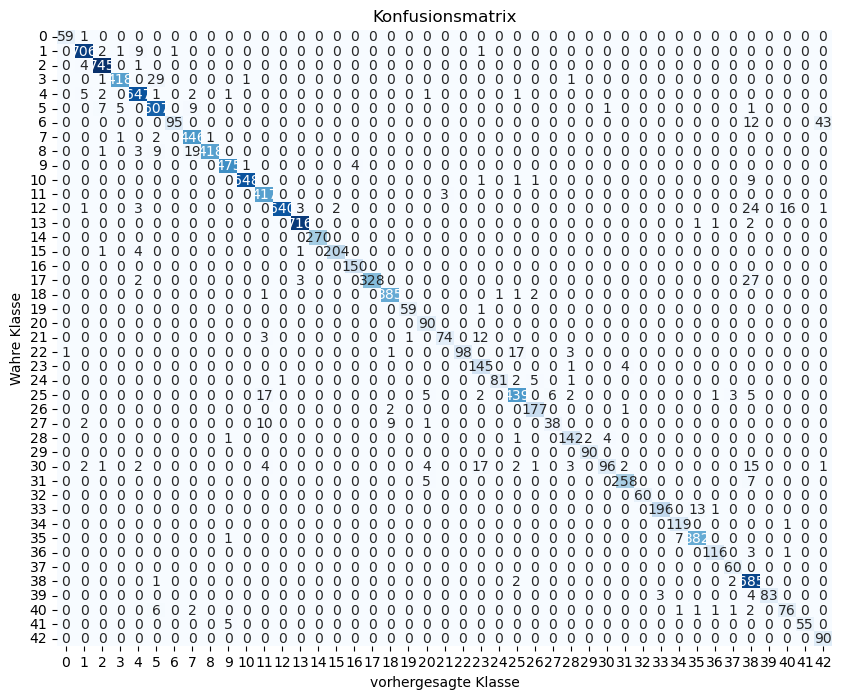

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

#Verwendung von Seaborn für eine benutzerfreundlichere Visualisierung der Konfusionsmatrix.
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("vorhergesagte Klasse")
plt.ylabel("Wahre Klasse")
plt.title("Konfusionsmatrix")
plt.show()

#### WIEDERSPEICHERUNG DES MODELLS

In [35]:
#Wiederspeicherung des Modells
save_model(loaded_model, "model.final.keras")
print("Model saved to disk")

Model saved to disk
